In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d rawatjitesh/avengers-face-recognition

Dataset URL: https://www.kaggle.com/datasets/rawatjitesh/avengers-face-recognition
License(s): copyright-authors
  0% 0.00/54.5M [00:00<?, ?B/s]
100% 54.5M/54.5M [00:00<00:00, 1.71GB/s]


In [ ]:
!unzip avengers-face-recognition.zip

Archive:  avengers-face-recognition.zip
  inflating: cropped_images/chris_evans/chris_evans1.png  
  inflating: cropped_images/chris_evans/chris_evans10.png  
  inflating: cropped_images/chris_evans/chris_evans11.png  
  inflating: cropped_images/chris_evans/chris_evans12.png  
  inflating: cropped_images/chris_evans/chris_evans13.png  
  inflating: cropped_images/chris_evans/chris_evans14.png  
  inflating: cropped_images/chris_evans/chris_evans15.png  
  inflating: cropped_images/chris_evans/chris_evans16.png  
  inflating: cropped_images/chris_evans/chris_evans17.png  
  inflating: cropped_images/chris_evans/chris_evans18.png  
  inflating: cropped_images/chris_evans/chris_evans19.png  
  inflating: cropped_images/chris_evans/chris_evans2.png  
  inflating: cropped_images/chris_evans/chris_evans20.png  
  inflating: cropped_images/chris_evans/chris_evans21.png  
  inflating: cropped_images/chris_evans/chris_evans22.png  
  inflating: cropped_images/chris_evans/chris_evans23.png  
  

In [ ]:
!pip install facenet_pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 832.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12

In [ ]:
import torch
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using Devicee:", device)

Using Devicee: cuda


In [ ]:
import os
import random
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from facenet_pytorch import MTCNN, InceptionResnetV1

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.manifold import TSNE
import seaborn as sns

making dataset directory path

In [ ]:
DATA_DIR = Path("/content/cropped_images")
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print("CLASSES:", classes)

for cls in classes:

  print(cls, ":", len(list((DATA_DIR/cls).glob("*"))), "images")

CLASSES: ['chris_evans', 'chris_hemsworth', 'mark_ruffalo', 'robert_downey_jr', 'scarlett_johansson']
chris_evans : 50 images
chris_hemsworth : 53 images
mark_ruffalo : 66 images
robert_downey_jr : 51 images
scarlett_johansson : 54 images


Visualizing some images from the dataset

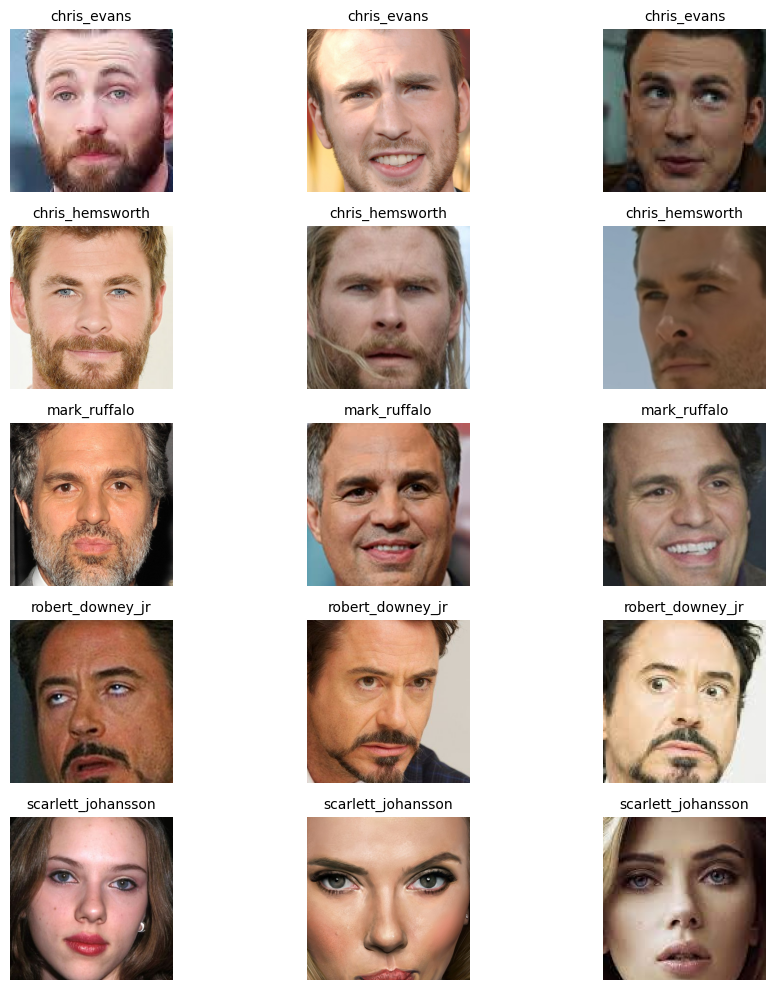

In [ ]:
def visulize_img(data_dir, classes, per_class=3):
  plt.figure(figsize=(10,10))
  i=1

  for cls in classes:
    paths = list((data_dir/cls).glob("*"))
    random.shuffle(paths)
    for path in paths[:per_class]:
      img = Image.open(path).convert("RGB")
      plt.subplot(len(classes), per_class, i)
      plt.imshow(img)
      plt.axis("off")
      plt.title(cls, fontsize=10) # Set title for each image to display class name
      i+=1
  plt.tight_layout()
  plt.show()

visulize_img(DATA_DIR, classes, per_class=3)

Initialize MTCNN for face detection and alignment

In [ ]:

mtcnn = MTCNN(
    image_size=160,
    margin=0,
    min_face_size=20,
    thresholds=[0.6,0.7,0.7],
    keep_all=False,
    device=device
)

In [ ]:
Aligned_dir = Path("aligned_faces")
Aligned_dir.mkdir(exist_ok=True)

for cls in classes:
  (Aligned_dir/cls).mkdir(exist_ok=True)

In [ ]:
def algin_face(input_path, output_path):
  img = Image.open(input_path).convert("RGB")
  try:
    face = mtcnn(img)
  except:
    face = None
  if face is None:
    Image.open(input_path).convert("RGB").resize((160,160)).save(output_path)
    return
  face = face.permute(1,2,0).cpu().numpy()
  face_img =Image.fromarray((face*127.5 + 127.5).astype(np.uint8))
  face_img.save(output_path)

for cls in classes:
  paths = list((DATA_DIR/cls).glob("*"))
  for p in tqdm(paths, desc=f"Aligning {cls}"):
    algin_face(p, Aligned_dir/cls/p.name)

Aligning scarlett_johansson: 100%|██████████| 54/54 [00:03<00:00, 15.24it/s]


In [ ]:
# Creating Custom Dataset
class AvengersDataset(Dataset):
  def __init__(self, root, transform=None):
    self.root = Path(root)
    self.transform = transform
    self.samples =[]

    for cls in sorted(os.listdir(root)):
      folder = self.root/cls
      for f in folder.glob("*"):
        self.samples.append((str(f), cls))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    path, label = self.samples[idx]
    img = Image.open(path).convert("RGB")
    if self.transform:
      img = self.transform(img)
    return img,label, path

transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # required for FaceNet
])

dataset = AvengersDataset(Aligned_dir, transform)
print('Total:', len(dataset))

Total: 274


loading facenet embedding model

In [ ]:
facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

  0%|          | 0.00/107M [00:00<?, ?B/s]

Extracting embedding for all images in dtaset

In [ ]:
loader = DataLoader(dataset, batch_size=32, shuffle=False)

embeddings =[]
labels =[]
paths = []

with torch.no_grad():
  for imgs,lbls,pths in tqdm(loader, desc="Extracting embedding"):
    imgs =imgs.to(device)
    embs = facenet(imgs).cpu().numpy()
    embeddings.append(embs)
    labels.extend(lbls)
    paths.extend(pths)

embeddings = np.vstack(embeddings)
labels = np.array(labels)

print("\nEmbedding Shape is ", embeddings.shape)

Extracting embedding: 100%|██████████| 9/9 [00:00<00:00,  9.64it/s]


Embedding Shape is  (274, 512)


In [ ]:
le = LabelEncoder()
y = le.fit_transform(labels)

In [ ]:
x_train, x_temp, y_train, y_temp, path_train, path_temp = train_test_split(embeddings, y, paths, test_size=0.30, stratify=y, random_state=42)
x_val, x_test, y_val, y_test, path_val, path_test = train_test_split(x_temp, y_temp, path_temp, test_size=0.5,stratify=y_temp, random_state=42)

print("Train:", len(x_train), "Val:", len(x_val), "Test:", len(x_test))

scaler = StandardScaler()
X_train_s = scaler.fit_transform(x_train)
X_val_s = scaler.transform(x_val)
X_test_s = scaler.transform(x_test)

Train: 191 Val: 41 Test: 42


In [ ]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_train_s, y_train)

SVC(probability=True)


Test accuracy: 1.0
                    precision    recall  f1-score   support

       chris_evans       1.00      1.00      1.00         8
   chris_hemsworth       1.00      1.00      1.00         8
      mark_ruffalo       1.00      1.00      1.00        10
  robert_downey_jr       1.00      1.00      1.00         8
scarlett_johansson       1.00      1.00      1.00         8

          accuracy                           1.00        42
         macro avg       1.00      1.00      1.00        42
      weighted avg       1.00      1.00      1.00        42



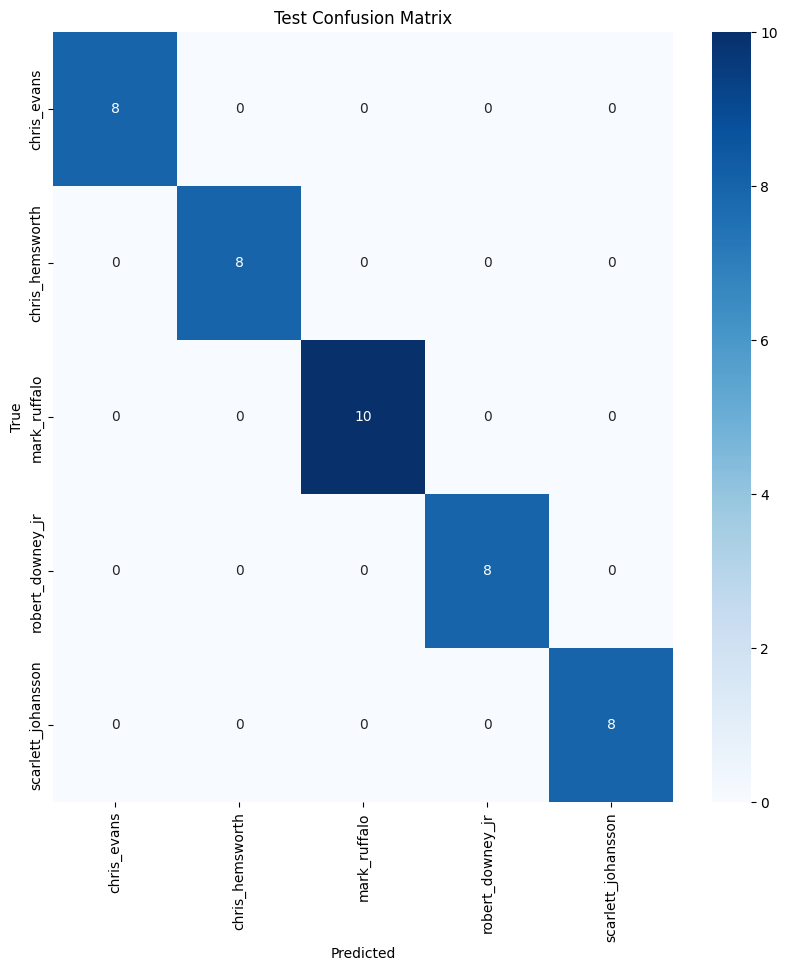

In [ ]:
def evaluate(model, x, y, label="Test"):
  pred = model.predict(x)
  print(f"\n{label} accuracy:", accuracy_score(y, pred))
  print(classification_report(y, pred, target_names=le.classes_))

  cm = confusion_matrix(y, pred)
  plt.figure(figsize=(10,10))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
  plt.title(label + " Confusion Matrix")
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.show()
  return pred
pred_test = evaluate(svm, X_test_s, y_test, "Test")

In [ ]:
mis_idx = np.where(pred_test != y_test)[0]
print("Misclassified:", len(mis_idx))

def show_misclassified(idx_list, paths_list, y_true, y_pred, max_show=8):
    plt.figure(figsize=(12,6))
    for i, idx in enumerate(idx_list[:max_show]):
        img = Image.open(paths_list[idx]).convert("RGB")
        plt.subplot(2,4,i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"T:{le.classes_[y_true[idx]]}\nP:{le.classes_[y_pred[idx]]}")

show_misclassified(mis_idx, path_test, y_test, pred_test)


Misclassified: 0


<Figure size 1200x600 with 0 Axes>

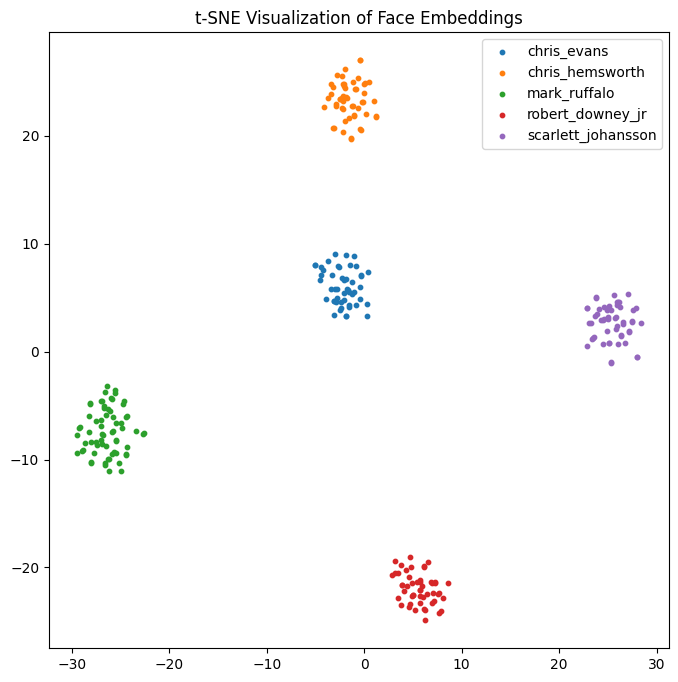

In [57]:
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,8))
for cls in np.unique(y):
    idx = np.where(y == cls)
    plt.scatter(X_2d[idx,0], X_2d[idx,1], label=le.classes_[cls], s=10)

plt.legend()
plt.title("t-SNE Visualization of Face Embeddings")
plt.show()


In [ ]:
import requests
from io import BytesIO

def predict_custom_image(source):
  if source.startswith("http"):
    print("loading image form the url")
    response = requests.get(source)
    img = Image.open(BytesIO(response.content)).convert("RGB")
  else:
    print("Loading image from local path")
    img = Image.open(source).convert("RGB")

  # detect face
  face = mtcnn(img)
  if face is None:
      print("No face detected.")
      return

  face = face.to(device).unsqueeze(0)

  # embedding
  with torch.no_grad():
      emb = facenet(face).cpu().numpy()

  emb_s = scaler.transform(emb)
  prob = svm.predict_proba(emb_s)[0]
  pred = svm.predict(emb_s)[0]
  name = le.classes_[pred]

  print("Predicted:", name)
  print("Probabilities:")
  for i,c in enumerate(le.classes_):
      print(f"{c}: {prob[i]:.4f}")

  plt.imshow(img)
  plt.title(f"Predicted: {name}")
  plt.axis("off")
  plt.show()

loading image form the url
Predicted: scarlett_johansson
Probabilities:
chris_evans: 0.0735
chris_hemsworth: 0.0206
mark_ruffalo: 0.0407
robert_downey_jr: 0.0476
scarlett_johansson: 0.8176


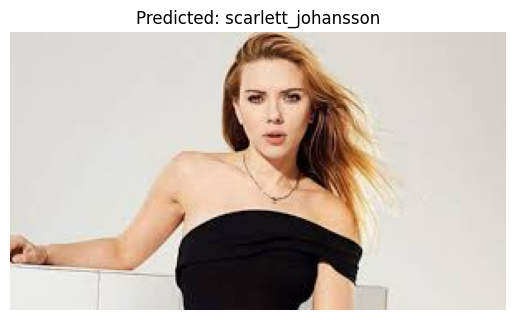

In [42]:
predict_custom_image("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTPM4FRpQoFFlYzvcxMxuKhfBNgP8T-GEliAQ&s")

loading image form the url
Predicted: chris_hemsworth
Probabilities:
chris_evans: 0.1997
chris_hemsworth: 0.3908
mark_ruffalo: 0.2046
robert_downey_jr: 0.0997
scarlett_johansson: 0.1052


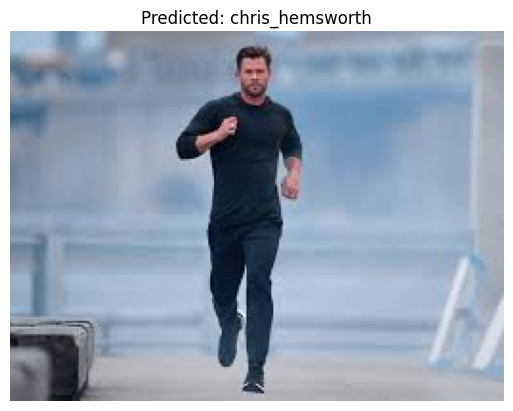

In [41]:
predict_custom_image("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQSMF8KQnxprUt6EuOpmcwMtcKJ0cQtzRD4fA&s")